In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler

In [14]:
local_dataset = pd.read_csv("../data/local/cebu.csv")
local_dataset.head()

,Patient,Age,Height (cm),Weight (kg),Body Mass Index (BMI),Blood Pressure,Menstrual Irregularities,Symptoms,Ultrasound Findings,Gravida
0,P1,34,1.57,64.0,25.9645,120/80,Irregular,"irregular masses, weight gain, hirsutism",PCO,G0P0
1,P2,22,1.53,52.0,22.2137,120/80,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
2,P3,19,1.55,55.0,22.8928,110/70,Regular,"irregular masses, acne",PCO,G0P0
3,P4,24,1.55,55.0,22.8928,110/70,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
4,P5,25,1.59,50.0,19.7777,110/71,Regular,irregular masses,PCO,G0P0


In [15]:
from adapter import Dataset1Adapter, LocalDatasetAdapter

In [16]:
adapter = LocalDatasetAdapter(local_dataset)
preprocessed_local_dataset = adapter.convert()

/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.infertility] = filtered_dataframe[features.infertility].apply(lambda x: 1 if x == 'G1P0' or x == 'G3P2' else 0)
/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.menstrual_irregularity] = filtered_dataframe[features.menstrual_irregularity].apply(

[Text(0, 0, 'No PCOS'), Text(1, 0, 'PCOS')]

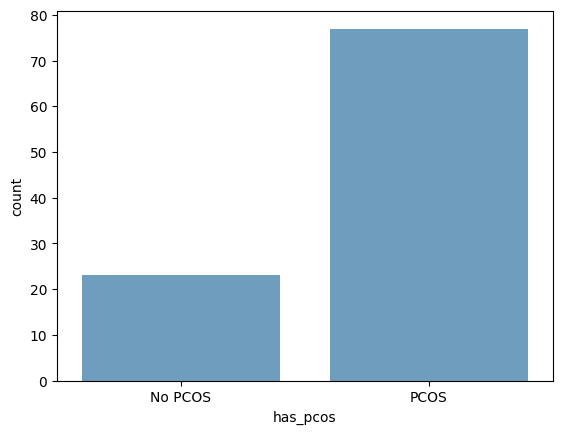

In [17]:
# plot dataset distribution for target variable of 1 and 0
ax = sns.countplot(data=preprocessed_local_dataset, x='has_pcos', alpha=0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No PCOS', 'PCOS'])

In [18]:
# # MinMaxScaler
# preprocessed_local_dataset['bmi'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['bmi']])
# preprocessed_local_dataset['age'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['age']])

In [19]:
# Define features and target variable
X = preprocessed_local_dataset.drop(columns=['has_pcos'])
y = preprocessed_local_dataset['has_pcos']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [20]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import accuracy_score

In [21]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred_val = rf.predict(X_test)
    return accuracy_score(y_test, y_pred_val)

In [22]:

# Apply Tree-structured Parzen Estimator (TPE) Bayesian Optimization
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print("Best Parameters found via Parzen Tree (TPE):", study.best_trial.params)

[I 2026-06-03 21:47:07,558] A new study created in memory with name: no-name-8a002ec0-8f11-4e0e-9b14-322caa7328cc
[I 2026-06-03 21:47:07,605] Trial 0 finished with value: 0.9 and parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 8}. Best is trial 0 with value: 0.9.
[I 2026-06-03 21:47:07,657] Trial 1 finished with value: 0.9 and parameters: {'n_estimators': 140, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 0 with value: 0.9.
[I 2026-06-03 21:47:07,679] Trial 2 finished with value: 0.8666666666666667 and parameters: {'n_estimators': 58, 'max_depth': 18, 'min_samples_split': 7}. Best is trial 0 with value: 0.9.
[I 2026-06-03 21:47:07,735] Trial 3 finished with value: 0.9 and parameters: {'n_estimators': 156, 'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: 0.9.
[I 2026-06-03 21:47:07,798] Trial 4 finished with value: 0.9333333333333333 and parameters: {'n_estimators': 175, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 4 with v

Best Parameters found via Parzen Tree (TPE): {'n_estimators': 175, 'max_depth': 6, 'min_samples_split': 3}


In [23]:

# Train model with best parameters
rf_classifier = RandomForestClassifier(**study.best_trial.params, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 3  2]
 [ 0 25]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.93      1.00      0.96        25

    accuracy                           0.93        30
   macro avg       0.96      0.80      0.86        30
weighted avg       0.94      0.93      0.93        30



In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# K-fold validation using best parameters found by TPE (Parzen estimator)
best_rf = RandomForestClassifier(**study.best_trial.params, random_state=42)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_rf, X, y, cv=kfold, scoring='accuracy')

print("K-Fold Accuracy Scores:", cv_scores)
print(f"Mean K-Fold Accuracy: {cv_scores.mean():.4f}")
print(f"Std K-Fold Accuracy: {cv_scores.std():.4f}")

K-Fold Accuracy Scores: [0.85 0.9  0.7  0.75 0.8 ]
Mean K-Fold Accuracy: 0.8000
Std K-Fold Accuracy: 0.0707


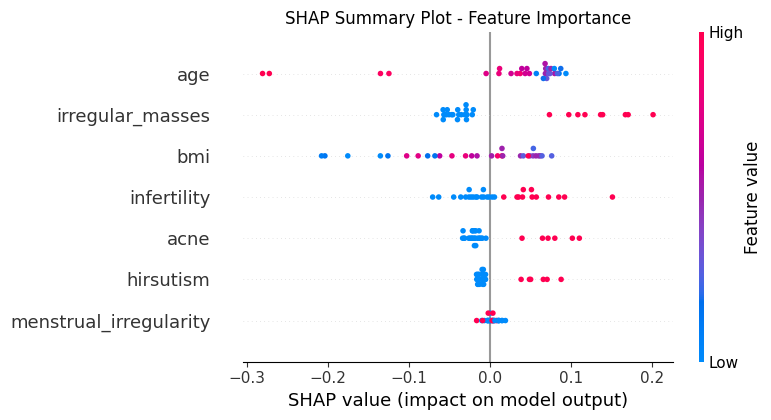

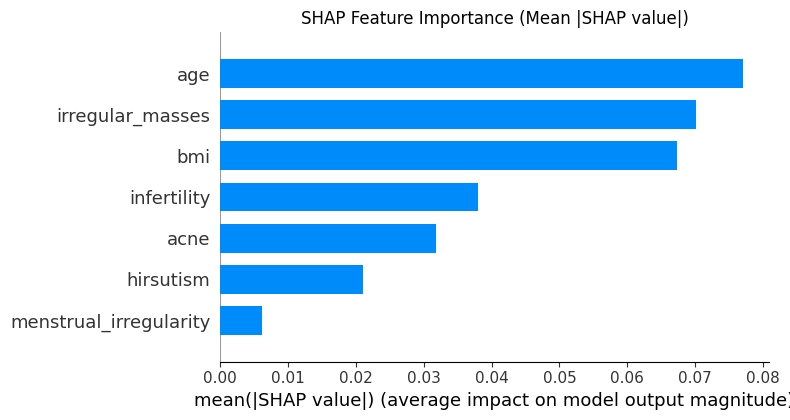


Feature names: ['bmi', 'age', 'infertility', 'menstrual_irregularity', 'acne', 'hirsutism', 'irregular_masses']


In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the RF model
explainer = shap.TreeExplainer(rf_classifier)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Handle different shap input formats depending on the SHAP version
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif len(shap_values.shape) == 3:
    # 3D array (n_samples, n_features, n_classes)
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

# Summary plot - shows feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_positive, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout()
plt.show()

# Bar plot - average impact on model output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_positive, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

print("\nFeature Importance (by mean absolute SHAP value):")
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)
print(feature_importance)

# Conclusion